# Seminário I - Cálculo Numérico

## Bibliotecas Utilizadas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

## Condição de Aplicabilidade - Teorema de Bolzano

###
1. Verifica se existe uma raiz no intervalo $[a, b]$:

$$f(a) \cdot f(b) < 0$$

Se o produto for negativo os sinais são opostos => há pelo menos uma raíz no intervalo.

In [2]:
def verificar_intervalo(f, a, b):
    """Verifica o Teorema de Bolzano para o intervalo [a, b]."""
    fa, fb = f(a), f(b)
    if fa * fb < 0:
        print(f"Intervalo válido: f({a}) = {fa:.4f}  |  f({b}) = {fb:.4f}")
        print(f"   f(a)·f(b) = {fa*fb:.4f} < 0  -> Existe raiz em [{a}, {b}]")
        return True
    else:
        print(f"Intervalo inválido: f({a}) = {fa:.4f}  |  f({b}) = {fb:.4f}")
        print(f"   f(a)·f(b) = {fa*fb:.4f} ≥ 0  -> Não é garantida raiz em [{a}, {b}]")
        return False

## Método I - Bissecção

###
Bissecção: Divide o intervalo ao meio a cada iteração

A cada passo, calcula o **ponto médio** $m = \dfrac{a+b}{2}$ e descarta a metade do intervalo onde não há troca de sinal.

### Critério de parada
$$|b - a| < \varepsilon \quad \text{ou} \quad |f(m)| < \varepsilon$$

### Convergência
O erro diminui exatamente pela metade a cada iteração: $E_n = \dfrac{b-a}{2^n}$

In [3]:
def bisseccao(f, a, b, tol=1e-6, max_iter=100, verbose=True):
    """
    Método da Bissecção para encontrar raiz de f em [a, b].

    Parâmetros:
        f        : função contínua
        a, b     : extremos do intervalo (f(a)*f(b) < 0)
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")

    historico = []

    if verbose:
        print(f"{'Iter':>5} {'a':>12} {'b':>12} {'m':>12} {'f(m)':>14} {'|b-a|':>12}")
        print("-" * 73)

    for i in range(1, max_iter + 1):
        m = (a + b) / 2
        fm = f(m)
        erro = abs(b - a)

        historico.append({'iter': i, 'a': a, 'b': b, 'm': m, 'fm': fm, 'erro': erro})

        if verbose:
            print(f"{i:>5} {a:>12.6f} {b:>12.6f} {m:>12.6f} {fm:>14.8f} {erro:>12.2e}")

        if erro < tol or abs(fm) < tol:
            break

        if f(a) * fm < 0:
            b = m
        else:
            a = m

    if verbose:
        print(f"\nRaiz encontrada: x ≈ {m:.8f}  |  f(x) ≈ {fm:.2e}  |  Iterações: {i}")

    return m, historico

## Método II - Falsa Posição

###

Falsa Posição: Usa interpolação linear para estimar a raiz

Em vez do ponto médio, usa a **reta secante** que passa por $(a,  f(a))$ e $(b,  f(b))$, e toma o ponto onde essa reta cruza o eixo $x$:

$$x_r = b - f(b) \cdot \frac{b - a}{f(b) - f(a)}$$

### Convergência
Geralmente mais rápida que a Bissecção, mas pode ser lenta em casos de curvatura acentuada (problema do "lado preso").

In [4]:
def falsa_posicao(f, a, b, tol=1e-6, max_iter=100, verbose=True):
    """
    Método da Falsa Posição (Regula Falsi) para encontrar raiz de f em [a, b].

    Parâmetros:
        f        : função contínua
        a, b     : extremos do intervalo (f(a)*f(b) < 0)
        tol      : tolerância de parada
        max_iter : número máximo de iterações
        verbose  : imprime tabela de iterações

    Retorna:
        raiz, historico (lista de dicionários com dados de cada iteração)
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) e f(b) devem ter sinais opostos.")

    historico = []

    if verbose:
        print(f"{'Iter':>5} {'a':>12} {'b':>12} {'xr':>12} {'f(xr)':>14} {'|b-a|':>12}")
        print("-" * 73)

    xr_ant = a  # valor anterior para critério de parada relativo

    for i in range(1, max_iter + 1):
        fa, fb = f(a), f(b)
        xr = b - fb * (b - a) / (fb - fa)   # fórmula da falsa posição
        fxr = f(xr)
        erro = abs(b - a)

        historico.append({'iter': i, 'a': a, 'b': b, 'xr': xr, 'fxr': fxr, 'erro': erro})

        if verbose:
            print(f"{i:>5} {a:>12.6f} {b:>12.6f} {xr:>12.6f} {fxr:>14.8f} {erro:>12.2e}")

        if abs(fxr) < tol or erro < tol:
            break

        if fa * fxr < 0:
            b = xr
        else:
            a = xr

        xr_ant = xr

    if verbose:
        print(f"\nRaiz encontrada: x ≈ {xr:.8f}  |  f(x) ≈ {fxr:.2e}  |  Iterações: {i}")

    return xr, historico

## Funções para visualizar os exemplos

In [5]:
def plotar_funcao_e_raiz(f, a, b, raiz_b, raiz_fp, titulo="", nome_funcao="f(x)"):
    """Plota a função com as raízes encontradas pelos dois métodos."""
    x = np.linspace(a - 0.5, b + 0.5, 800)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label=nome_funcao)
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)
    ax.axvline(a, color='#aaa', lw=1, ls=':', alpha=0.5, label=f'a = {a}')
    ax.axvline(b, color='#aaa', lw=1, ls=':', alpha=0.5, label=f'b = {b}')

    ax.scatter([raiz_b],  [f(raiz_b)],  color='#ff6b6b', s=120, zorder=5, label=f'Bissecção:      x ≈ {raiz_b:.6f}')
    ax.scatter([raiz_fp], [f(raiz_fp)], color='#ffd93d', s=120, zorder=5, marker='D', label=f'Falsa Posição: x ≈ {raiz_fp:.6f}')

    ax.set_title(titulo, fontsize=13, pad=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plotar_convergencia(hist_b, hist_fp):
    """Compara a convergência dos dois métodos (erro × iteração)."""
    erros_b  = [h['erro'] for h in hist_b]
    erros_fp = [h['erro'] for h in hist_fp]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.semilogy(range(1, len(erros_b) + 1),  erros_b,  'o-', color='#ff6b6b', lw=2, ms=5, label='Bissecção')
    ax.semilogy(range(1, len(erros_fp) + 1), erros_fp, 's-', color='#ffd93d', lw=2, ms=5, label='Falsa Posição')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('Erro  |b − a|  (escala log)')
    ax.set_title('Convergência: Bissecção vs Falsa Posição', fontsize=12)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plotar_iteracoes_bisseccao(f, hist, a_ini, b_ini, n_mostrar=5):
    """Visualiza as primeiras iterações da Bissecção no gráfico da função."""
    x = np.linspace(a_ini - 0.3, b_ini + 0.3, 600)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.plasma(np.linspace(0.2, 0.9, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        m = h['m']
        ax.axvline(m, color=cores[k], lw=1.2, ls='--', alpha=0.8, label=f'Iter {h["iter"]}: m={m:.4f}')
        ax.scatter([m], [f(m)], color=cores[k], s=60, zorder=5)

    ax.set_title(f'Bissecção — primeiras {n_mostrar} iterações', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()


def plotar_iteracoes_falsa_posicao(f, hist, a_ini, b_ini, n_mostrar=5):
    """Visualiza as primeiras iterações da Falsa Posição (mostra a reta secante)."""
    x = np.linspace(a_ini - 0.3, b_ini + 0.3, 600)
    y = f(x)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x, y, color='#00d4ff', lw=2.5, label='f(x)')
    ax.axhline(0, color='#ffffff', lw=0.8, alpha=0.4)

    cores = plt.cm.inferno(np.linspace(0.2, 0.85, n_mostrar))
    for k, h in enumerate(hist[:n_mostrar]):
        a_k, b_k, xr = h['a'], h['b'], h['xr']
        # reta secante
        ax.plot([a_k, b_k], [f(a_k), f(b_k)], color=cores[k], lw=1.2, ls='--', alpha=0.7)
        ax.scatter([xr], [0], color=cores[k], s=70, zorder=5, label=f'Iter {h["iter"]}: xr={xr:.4f}')

    ax.set_title(f'Falsa Posição — primeiras {n_mostrar} iterações (retas secantes)', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

## Exemplos de Aplicação

### Exemplo 1 — $f(x) = x^3 - x - 2$

Raiz real conhecida: $x \approx 1.5214$

#### Definição da função do exemplo 1

In [6]:
def f1(x):
    return x**3 - x - 2

a1, b1 = 1.0, 2.0

print("=" * 56)
print("  Exemplo 1: f(x) = x³ - x - 2   |   Intervalo [1, 2]")
print("=" * 56)

verificar_intervalo(f1, a1, b1)

  Exemplo 1: f(x) = x³ - x - 2   |   Intervalo [1, 2]
Intervalo válido: f(1.0) = -2.0000  |  f(2.0) = 4.0000
   f(a)·f(b) = -8.0000 < 0  -> Existe raiz em [1.0, 2.0]


True

#### Bissecção

In [7]:
print("\n BISSECÇÃO\n")
raiz_b1, hist_b1 = bisseccao(f1, a1, b1, tol=1e-6)


 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.500000    -0.12500000     1.00e+00
    2     1.500000     2.000000     1.750000     1.60937500     5.00e-01
    3     1.500000     1.750000     1.625000     0.66601562     2.50e-01
    4     1.500000     1.625000     1.562500     0.25219727     1.25e-01
    5     1.500000     1.562500     1.531250     0.05911255     6.25e-02
    6     1.500000     1.531250     1.515625    -0.03405380     3.12e-02
    7     1.515625     1.531250     1.523438     0.01225042     1.56e-02
    8     1.515625     1.523438     1.519531    -0.01097125     7.81e-03
    9     1.519531     1.523438     1.521484     0.00062218     3.91e-03
   10     1.519531     1.521484     1.520508    -0.00517889     1.95e-03
   11     1.520508     1.521484     1.520996    -0.00227944     9.77e-04
   12     1.520996     1.521484     1

#### Falsa Posição

In [8]:
print("\n FALSA POSIÇÃO\n")
raiz_fp1, hist_fp1 = falsa_posicao(f1, a1, b1, tol=1e-6)


 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.333333    -0.96296296     1.00e+00
    2     1.333333     2.000000     1.462687    -0.33333887     6.67e-01
    3     1.462687     2.000000     1.504019    -0.10181798     5.37e-01
    4     1.504019     2.000000     1.516331    -0.02989480     4.96e-01
    5     1.516331     2.000000     1.519919    -0.00867507     4.84e-01
    6     1.519919     2.000000     1.520957    -0.00250881     4.80e-01
    7     1.520957     2.000000     1.521258    -0.00072482     4.79e-01
    8     1.521258     2.000000     1.521344    -0.00020935     4.79e-01
    9     1.521344     2.000000     1.521370    -0.00006046     4.79e-01
   10     1.521370     2.000000     1.521377    -0.00001746     4.79e-01
   11     1.521377     2.000000     1.521379    -0.00000504     4.79e-01
   12     1.521379     2.000000  

#### Gráficos do exemplo 1

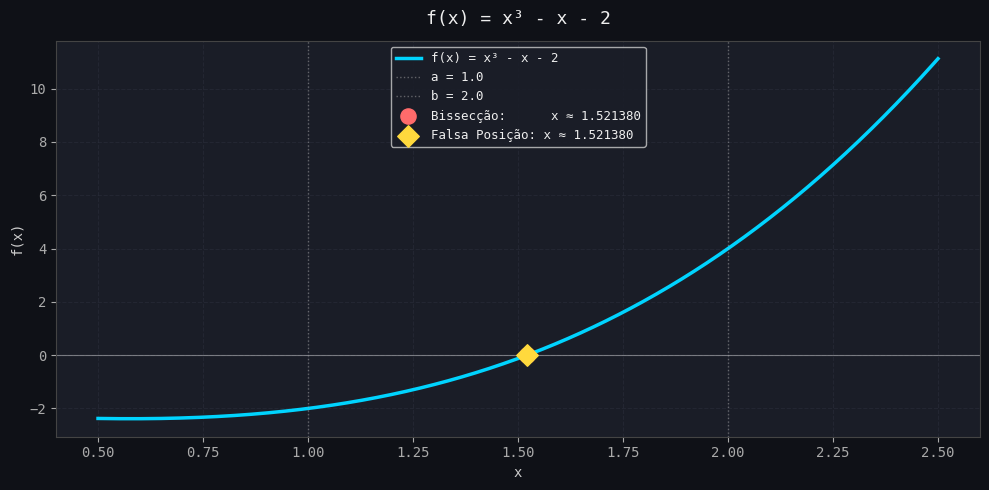

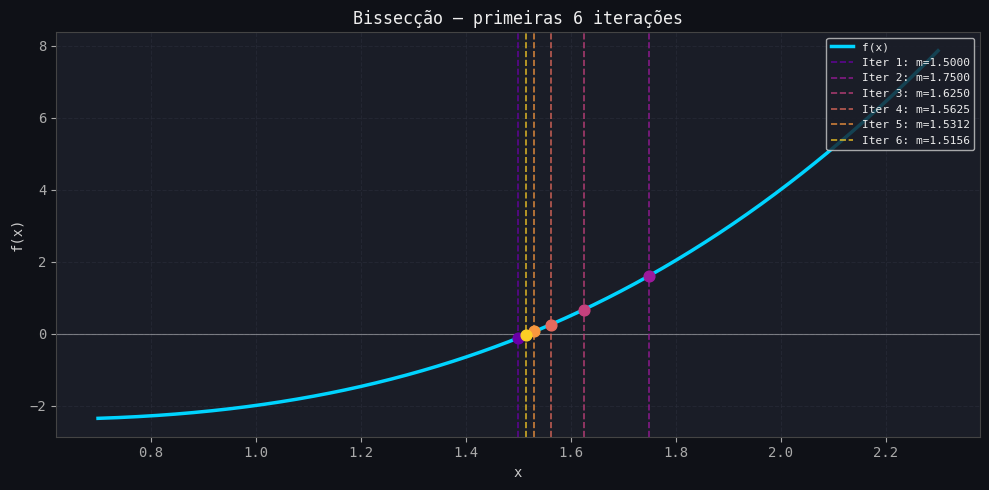

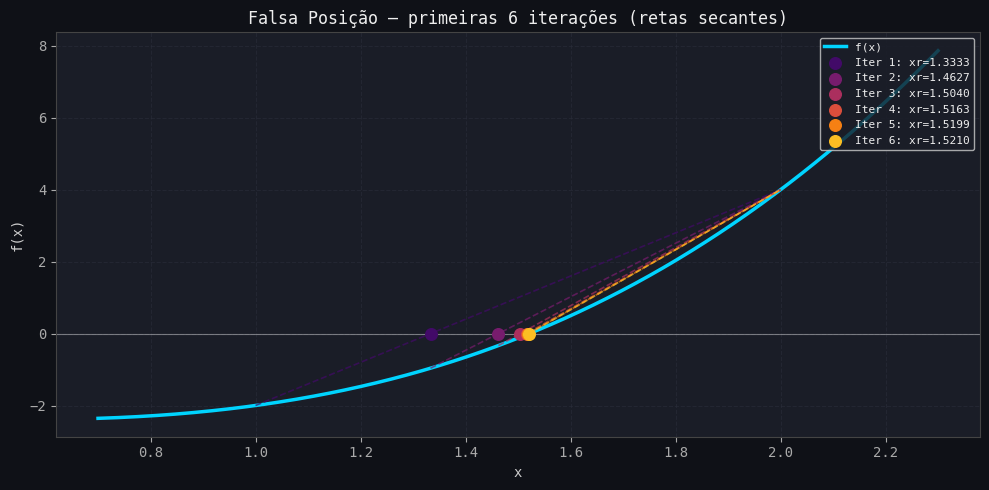

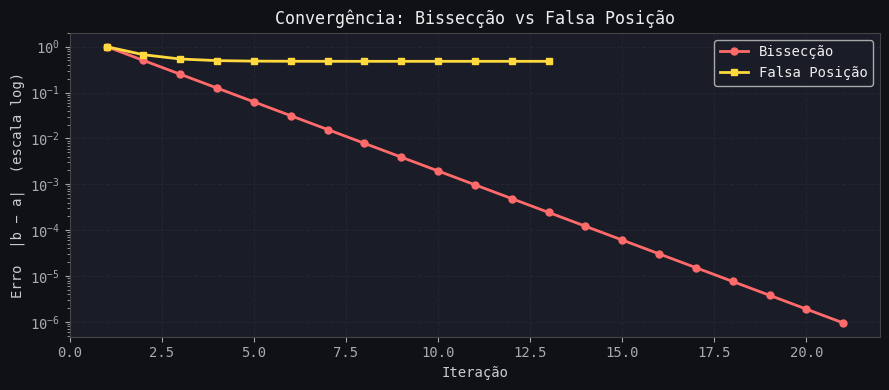

In [9]:
plotar_funcao_e_raiz(f1, a1, b1, raiz_b1, raiz_fp1,
                     titulo="f(x) = x³ - x - 2", nome_funcao="f(x) = x³ - x - 2")
plotar_iteracoes_bisseccao(f1, hist_b1, a1, b1, n_mostrar=6)
plotar_iteracoes_falsa_posicao(f1, hist_fp1, a1, b1, n_mostrar=6)
plotar_convergencia(hist_b1, hist_fp1)

### Exemplo 2 — $f(x) = e^x - 3x$

Função com dois zeros reais. Vamos buscar a raiz em $[1, 2]$.

#### Definição da função do exemplo 2

In [10]:
def f2(x):
    return np.exp(x) - 3*x

a2, b2 = 1.0, 2.0

print("=" * 56)
print("  Exemplo 2: f(x) = eˣ - 3x   |   Intervalo [1, 2]")
print("=" * 56)

verificar_intervalo(f2, a2, b2)

  Exemplo 2: f(x) = eˣ - 3x   |   Intervalo [1, 2]
Intervalo válido: f(1.0) = -0.2817  |  f(2.0) = 1.3891
   f(a)·f(b) = -0.3913 < 0  -> Existe raiz em [1.0, 2.0]


True

#### Bissecção

In [11]:
print("\n BISSECÇÃO\n")
raiz_b2, hist_b2 = bisseccao(f2, a2, b2, tol=1e-6)


 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.500000    -0.01831093     1.00e+00
    2     1.500000     2.000000     1.750000     0.50460268     5.00e-01
    3     1.500000     1.750000     1.625000     0.20341904     2.50e-01
    4     1.500000     1.625000     1.562500     0.08323318     1.25e-01
    5     1.500000     1.562500     1.531250     0.03020315     6.25e-02
    6     1.500000     1.531250     1.515625     0.00539040     3.12e-02
    7     1.500000     1.515625     1.507812    -0.00659811     1.56e-02
    8     1.507812     1.515625     1.511719    -0.00063845     7.81e-03
    9     1.511719     1.515625     1.513672     0.00236731     3.91e-03
   10     1.511719     1.513672     1.512695     0.00086227     1.95e-03
   11     1.511719     1.512695     1.512207     0.00011137     9.77e-04
   12     1.511719     1.512207     1

#### Falsa Posição

In [12]:
print("\n FALSA POSIÇÃO\n")
raiz_fp2, hist_fp2 = falsa_posicao(f2, a2, b2, tol=1e-6)


 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1     1.000000     2.000000     1.168615    -0.28831166     1.00e+00
    2     1.168615     2.000000     1.311517    -0.22275107     8.31e-01
    3     1.311517     2.000000     1.406665    -0.13767720     6.88e-01
    4     1.406665     2.000000     1.460170    -0.07381806     5.93e-01
    5     1.460170     2.000000     1.487411    -0.03661084     5.40e-01
    6     1.487411     2.000000     1.500574    -0.01746002     5.13e-01
    7     1.500574     2.000000     1.506773    -0.00817167     4.99e-01
    8     1.506773     2.000000     1.509658    -0.00379089     4.93e-01
    9     1.509658     2.000000     1.510993    -0.00175142     4.90e-01
   10     1.510993     2.000000     1.511608    -0.00080763     4.89e-01
   11     1.511608     2.000000     1.511892    -0.00037210     4.88e-01
   12     1.511892     2.000000  

#### Gráficos do exemplo 2

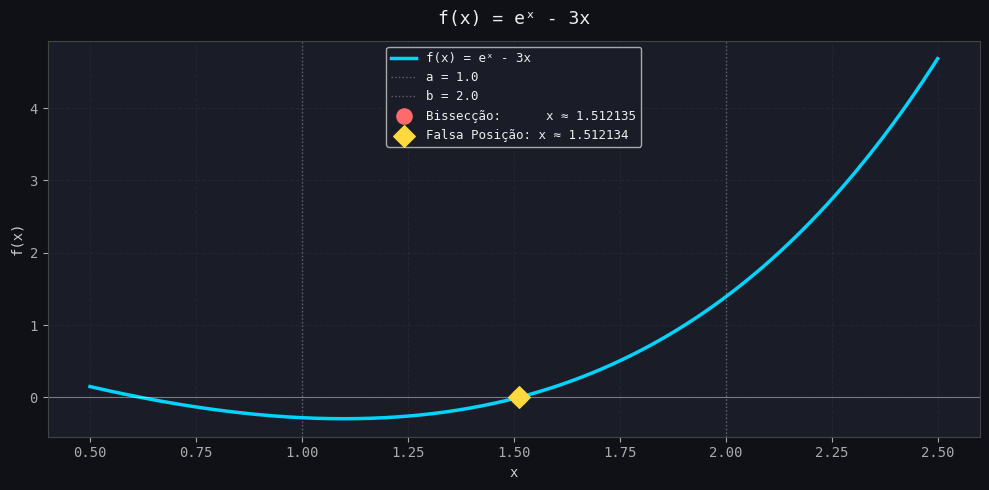

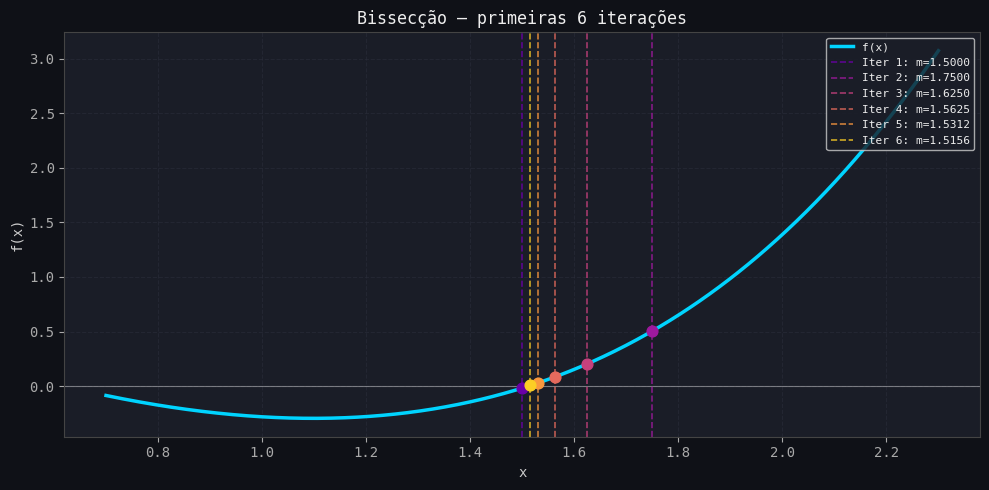

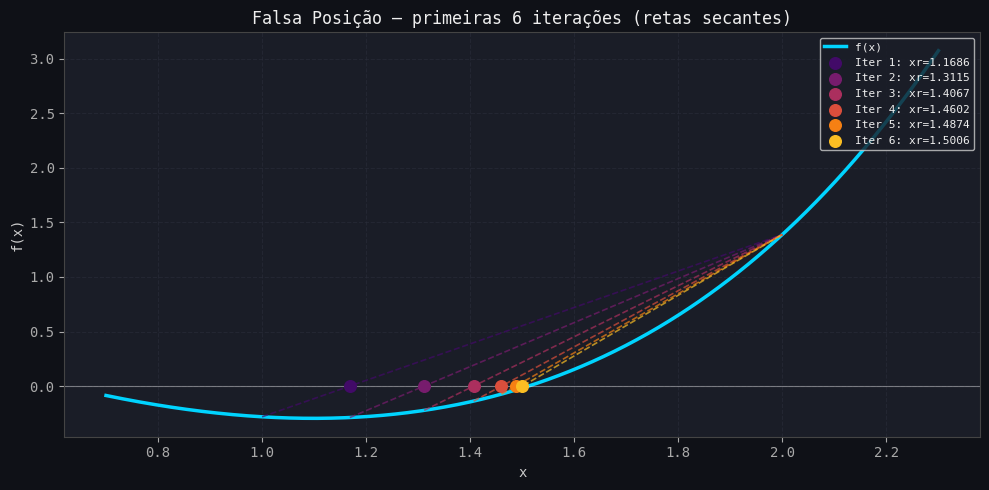

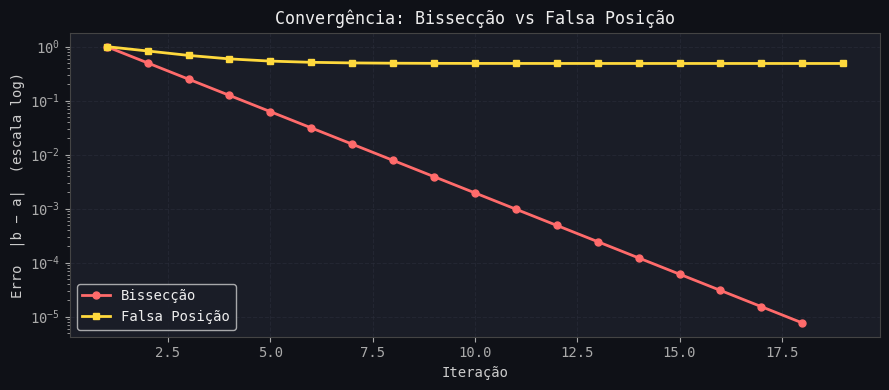

In [13]:
plotar_funcao_e_raiz(f2, a2, b2, raiz_b2, raiz_fp2,
                     titulo="f(x) = eˣ - 3x", nome_funcao="f(x) = eˣ - 3x")
plotar_iteracoes_bisseccao(f2, hist_b2, a2, b2, n_mostrar=6)
plotar_iteracoes_falsa_posicao(f2, hist_fp2, a2, b2, n_mostrar=6)
plotar_convergencia(hist_b2, hist_fp2)

### Exemplo 3 — $f(x) = \cos(x) - x$

Equação transcendente clássica. Ponto fixo de $\cos$.

#### Definição da função do exemplo 3

In [14]:
def f3(x):
    return np.cos(x) - x

a3, b3 = 0.0, 1.0

print("=" * 56)
print("  Exemplo 3: f(x) = cos(x) - x   |   Intervalo [0, 1]")
print("=" * 56)

verificar_intervalo(f3, a3, b3)

  Exemplo 3: f(x) = cos(x) - x   |   Intervalo [0, 1]
Intervalo válido: f(0.0) = 1.0000  |  f(1.0) = -0.4597
   f(a)·f(b) = -0.4597 < 0  -> Existe raiz em [0.0, 1.0]


True

#### Bissecção

In [15]:
print("\n BISSECÇÃO\n")
raiz_b3, hist_b3 = bisseccao(f3, a3, b3, tol=1e-8)


 BISSECÇÃO

 Iter            a            b            m           f(m)        |b-a|
-------------------------------------------------------------------------
    1     0.000000     1.000000     0.500000     0.37758256     1.00e+00
    2     0.500000     1.000000     0.750000    -0.01831113     5.00e-01
    3     0.500000     0.750000     0.625000     0.18596312     2.50e-01
    4     0.625000     0.750000     0.687500     0.08533495     1.25e-01
    5     0.687500     0.750000     0.718750     0.03387937     6.25e-02
    6     0.718750     0.750000     0.734375     0.00787473     3.12e-02
    7     0.734375     0.750000     0.742188    -0.00519571     1.56e-02
    8     0.734375     0.742188     0.738281     0.00134515     7.81e-03
    9     0.738281     0.742188     0.740234    -0.00192387     3.91e-03
   10     0.738281     0.740234     0.739258    -0.00028901     1.95e-03
   11     0.738281     0.739258     0.738770     0.00052816     9.77e-04
   12     0.738770     0.739258     0

#### Falsa Posição

In [16]:
print("\n FALSA POSIÇÃO\n")
raiz_fp3, hist_fp3 = falsa_posicao(f3, a3, b3, tol=1e-8)


 FALSA POSIÇÃO

 Iter            a            b           xr          f(xr)        |b-a|
-------------------------------------------------------------------------
    1     0.000000     1.000000     0.685073     0.08929928     1.00e+00
    2     0.685073     1.000000     0.736299     0.00466004     3.15e-01
    3     0.736299     1.000000     0.738945     0.00023393     2.64e-01
    4     0.738945     1.000000     0.739078     0.00001172     2.61e-01
    5     0.739078     1.000000     0.739085     0.00000059     2.61e-01
    6     0.739085     1.000000     0.739085     0.00000003     2.61e-01
    7     0.739085     1.000000     0.739085     0.00000000     2.61e-01

Raiz encontrada: x ≈ 0.73908513  |  f(x) ≈ 1.47e-09  |  Iterações: 7


#### Gráficos do exemplo 3

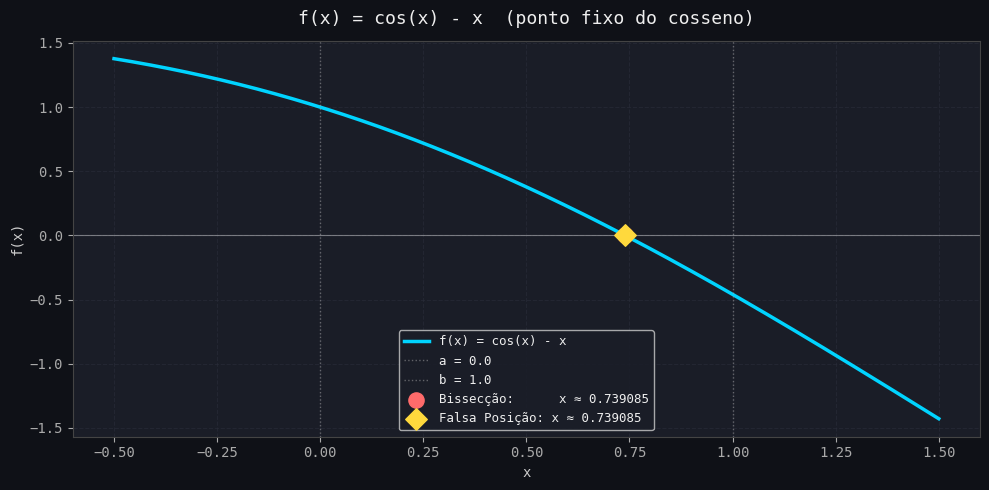

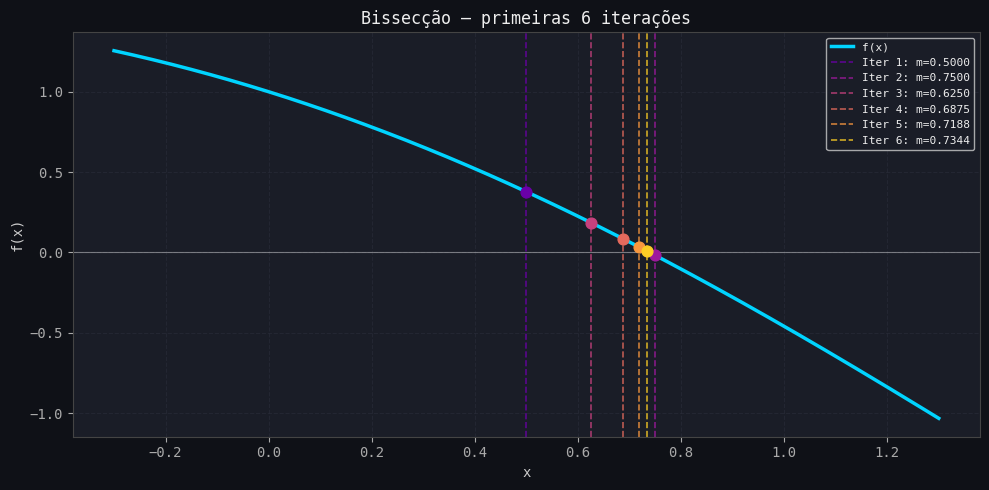

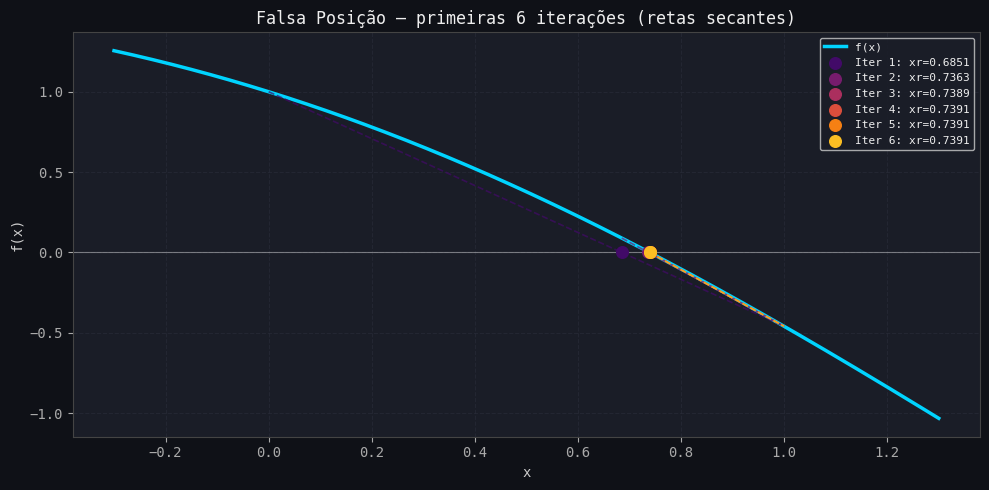

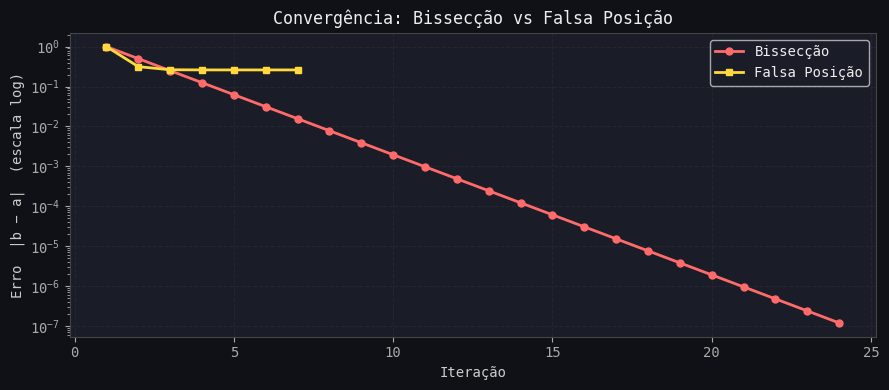

In [17]:
plotar_funcao_e_raiz(f3, a3, b3, raiz_b3, raiz_fp3,
                     titulo="f(x) = cos(x) - x  (ponto fixo do cosseno)",
                     nome_funcao="f(x) = cos(x) - x")
plotar_iteracoes_bisseccao(f3, hist_b3, a3, b3, n_mostrar=6)
plotar_iteracoes_falsa_posicao(f3, hist_fp3, a3, b3, n_mostrar=6)
plotar_convergencia(hist_b3, hist_fp3)

## Tabela de comparação dos resultados

In [18]:
def resumo_comparativo(nome_f, hist_b, raiz_b, hist_fp, raiz_fp):
    print(f"\n{'─'*60}")
    print(f"  Função: {nome_f}")
    print(f"  {'─'*58}")
    print(f"  {'Critério':<30} {'Bissecção':>12} {'Falsa Posição':>14}")
    print(f"  {'─'*58}")
    print(f"  {'Raiz encontrada':<30} {raiz_b:>12.8f} {raiz_fp:>14.8f}")
    print(f"  {'Nº de iterações':<30} {len(hist_b):>12d} {len(hist_fp):>14d}")
    print(f"  {'Erro final |f(raiz)|':<30} {abs(hist_b[-1]['fm']):>12.2e} {abs(hist_fp[-1]['fxr']):>14.2e}")
    print(f"{'─'*60}")

resumo_comparativo("x³ - x - 2",    hist_b1, raiz_b1, hist_fp1, raiz_fp1)
resumo_comparativo("eˣ - 3x",       hist_b2, raiz_b2, hist_fp2, raiz_fp2)
resumo_comparativo("cos(x) - x",    hist_b3, raiz_b3, hist_fp3, raiz_fp3)


────────────────────────────────────────────────────────────
  Função: x³ - x - 2
  ──────────────────────────────────────────────────────────
  Critério                          Bissecção  Falsa Posição
  ──────────────────────────────────────────────────────────
  Raiz encontrada                  1.52137995     1.52137964
  Nº de iterações                          21             13
  Erro final |f(raiz)|               1.43e-06       4.21e-07
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  Função: eˣ - 3x
  ──────────────────────────────────────────────────────────
  Critério                          Bissecção  Falsa Posição
  ──────────────────────────────────────────────────────────
  Raiz encontrada                  1.51213455     1.51213406
  Nº de iterações                          18             19
  Erro final |f(raiz)|               5.29e-10       7.51e-07
────────────────────────────────────────────

## Conclusão

### Tabela de comparação dos métodos

In [19]:
print(f"{'─'*104}")
print(f"  {'Aspecto':<37} {'Bissecção':<35} {'Falsa Posição':<35}")
print(f"  {'─'*102}")
print(f"  {'Garantia de Convergência':<37} {'Sempre converge':<35} {'Sempre converge':<35}")
print(f"  {'Velocidade':<37} {'Lenta (linear, fator 1/2)':<35} {'Geralmente mais rápida':<35}")
print(f"  {'Sensível à curva':<37} {'Não':<35} {'Sim (problema do lado preso)':<35}")
print(f"  {'Complexidade de Implementação':<37} {'Baixa':<35} {'Baixa':<35}")
print(f"  {'Nº de f por iteração':<37} {'1':<35} {'1':<35}")
print(f"{'─'*104}")

────────────────────────────────────────────────────────────────────────────────────────────────────────
  Aspecto                               Bissecção                           Falsa Posição                      
  ──────────────────────────────────────────────────────────────────────────────────────────────────────
  Garantia de Convergência              Sempre converge                     Sempre converge                    
  Velocidade                            Lenta (linear, fator 1/2)           Geralmente mais rápida             
  Sensível à curva                      Não                                 Sim (problema do lado preso)       
  Complexidade de Implementação         Baixa                               Baixa                              
  Nº de f por iteração                  1                                   1                                  
────────────────────────────────────────────────────────────────────────────────────────────────────────


### Quando usar cada método

In [20]:

print(f"{'─'*95}")
print(f"  {'':<25} {'Quando usar':<25}")
print(f"  {'─'*93}")
print(f"  {'Bissecção':<25} {'Convergência garantida e previsível':<25}")
print()
print(f"  {'Falsa Posição':<25} {'Convergência mais rápida e a função for bem comportada no intervalo':<25}")
print(f"{'─'*95}")

───────────────────────────────────────────────────────────────────────────────────────────────
                            Quando usar              
  ─────────────────────────────────────────────────────────────────────────────────────────────
  Bissecção                 Convergência garantida e previsível

  Falsa Posição             Convergência mais rápida e a função for bem comportada no intervalo
───────────────────────────────────────────────────────────────────────────────────────────────
